In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from thop import profile, clever_format

import csv
import time
import json
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe, data_reader
from loadData.split_data import HyperX2
from loadData.dataAugmentation import DataAugmentationDINO2

from utils import util, trainer, tester, infoNCE, CELoss, visulization, focalLoss
from models import resNet2, heads, vision_transformer, automaticWeightedLoss, CNNBase
from models.MS2CANet import pymodel

using GPU 1


In [2]:
args = opt.get_args()
# args.dataset_name = "Houston_2018"
args.dataset_name = "Houston_2013"
# args.dataset_name ="Berlin"

args.backbone = "resNet"
# args.backbone = "dino"
# args.backbone = "MS2CANet"


args.patch_size = 13
args.randomCrop = 11
args.components = 15
args.pca = True
args.awl = True

args.step_size = 30
args.gamma = 0.7
args.lambda_contra = 0.1
args.lambda_super = 1
args.lb_smooth = 0.1
# elif args.backbone == "MS2CANet":
# 	args.patch_size = 11
# 	args.randomCrop = 11
# 	args.batch_size = 64
# 	args.learning_rate = 0.001
# 	args.pca = True
# 	args.components = 20
# 	args.schedule = True
# 	args.step_size = 5
# 	args.gamma = 0.3

pca is used


<Figure size 1200x800 with 0 Axes>

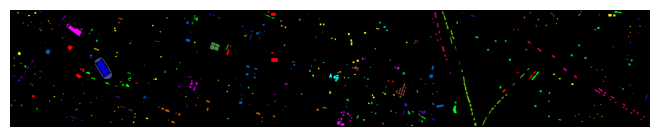

pca is used
print_data_info : ---->
class 1 	 178 	 20 	 1053
class 2 	 171 	 19 	 1064
class 3 	 173 	 19 	 505
class 4 	 169 	 19 	 1056
class 5 	 167 	 19 	 1056
class 6 	 164 	 18 	 143
class 7 	 176 	 20 	 1072
class 8 	 172 	 19 	 1053
class 9 	 174 	 19 	 1059
class 10 	 172 	 19 	 1036
class 11 	 163 	 18 	 1054
class 12 	 173 	 19 	 1041
class 13 	 166 	 18 	 285
class 14 	 163 	 18 	 247
class 15 	 168 	 19 	 473
total     	 2549 	 283 	 12197


In [3]:
# data_pipe.set_deterministic(seed = 666)
args.show_gt = True
args.print_data_info = False
args.remove_zero_labels = True
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt = data_pipe.get_data(args)
# print("img1", img1.shape, \
# 	  "img2", img2.shape, \
# 	  "train_gt", train_gt.shape, \
# 	  "val_gt", val_gt.shape, \
# 	  "test_gt", test_gt.shape, \
# 	  "data_gt", data_gt.shape)

height, wigth, data1_bands = img1.shape
height, wigth, data2_bands = img2.shape
transform = DataAugmentationDINO2(args)

contrastive_dataset = HyperX2(img1, img2, train_gt, transform=transform, 
					   patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)

args.show_gt = False
args.train_ratio = 0.9
args.print_data_info = True
args.remove_zero_labels = True
img1, img2, train_gt, val_gt, test_gt, data_gt = data_pipe.get_data(args)


train_dataset = HyperX2(img1, img2, train_gt, transform=None, 
						patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
val_dataset = HyperX2(img1, img2, val_gt, transform=None, 
					  patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)
test_dataset = HyperX2(img1, img2, test_gt, transform=None, 
					  patch_size=args.patch_size, remove_zero_labels=args.remove_zero_labels)


# 用于 focalloss
train_gt_pure = train_gt[train_gt > 0] - 1
test_gt_pure = test_gt[test_gt > 0] - 1
loss_weight = focalLoss.loss_weight_calculation(test_gt_pure)

contrastive_loader = DataLoader(contrastive_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)

class_num = np.max(train_gt)
# print(class_num, train_gt.shape, len(train_loader.dataset))

In [6]:
for x11, x12, x21, x22, y in contrastive_loader:
    print("x11.shape, x12.shape", x11.shape, x12.shape, len(x11))
    print("x21.shape, x22.shape", x21.shape, x22.shape, len(x21))

    # fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    # for i in range(9):
    #     ax = axes[i // 3, i % 3]
    #     img = x11[i].permute(1, 2, 0)[:, :, :3]  # 转为HWC格式，并取前3通道
    #     img = (img - img.min()) / (img.max() - img.min() + 1e-6)  # 归一化以避免显示错误
    #     ax.imshow(img)
    #     ax.axis('off')
      
    # plt.tight_layout(pad=0)  # 去除额外空白边距
    # plt.show()
    break

for x11, x21, y in train_loader:
    print("x11.shape", x11.shape)
    print("x21.shape", x21.shape)
    break

x11.shape, x12.shape torch.Size([256, 15, 11, 11]) torch.Size([256, 15, 11, 11]) 256
x21.shape, x22.shape torch.Size([256, 1, 11, 11]) torch.Size([256, 1, 11, 11]) 256
x11.shape torch.Size([256, 15, 13, 13])
x21.shape torch.Size([256, 1, 13, 13])


In [ ]:
# 加载已有权重路径
# args.result_dir = "/home/leo/Multimodal_Classification/KnowCLPlus/results/04-01-17-21-cnn_D3M"

args.result_dir = os.path.join("/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result",
                    datetime.now().strftime("%m-%d-%H-%M-" + args.backbone + "_D3"))
print(args.result_dir)

if not os.path.exists(args.result_dir):
    os.mkdir(args.result_dir)
with open(args.result_dir + '/args.json', 'w') as fid:
    json.dump(args.__dict__, fid, indent=2)

/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/08-01-08-22-resNet_D3


# model

In [ ]:
if args.backbone == "resNet":
    encoder = resNet2.ResNet(data1_bands, data2_bands).to(args.device)
    args.feature_dim = 512
    # args.feature_dim = 2048
    super_head = heads.FDGC_head(args.feature_dim, class_num=class_num).to(args.device)
    contra_head = heads.DINOHead(args.feature_dim).to(args.device)
    awl = automaticWeightedLoss.AutomaticWeightedLoss(2).to(args.device)
    params = list(super_head.parameters()) + list(contra_head.parameters()) \
        + list(encoder.parameters()) + list(awl.parameters())

elif args.backbone == "MS2CANet":
    FM = 64
    args.feature_dim = 256
    para_tune = False
    if args.dataset_name == "Houston_2013":
        para_tune = True                # para_tune 这个参数对于 Houston 的提升有两个点！！
    encoder = pymodel.pyCNN(FM=FM, NC=args.components, para_tune=para_tune).to(args.device)
    super_head = heads.MS2_head(args.feature_dim, class_num=class_num).to(args.device)
    contra_head = heads.DINOHead(args.feature_dim).to(args.device)
    awl = automaticWeightedLoss.AutomaticWeightedLoss(2).to(args.device)
    params = list(super_head.parameters()) + list(contra_head.parameters()) \
        + list(encoder.parameters()) + list(awl.parameters())


optimizer = optim.Adam(params, lr=args.learning_rate, weight_decay=args.weight_decay, amsgrad=True)
# optimizer = optim.Adam(params, lr=args.learning_rate, weight_decay=args.weight_decay)
criterion1 = torch.nn.CrossEntropyLoss()
criterion2 = CELoss.LabelSmoothSoftmaxCEV1(args.lb_smooth)
criterion3 = CELoss.SoftTargetCrossEntropy()
criterion4 = infoNCE.InfoNCE()
criterion5 = infoNCE.NT_xent_loss_W_EN()

warmup = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, e / 5.0))
decay = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.step_size, gamma=args.gamma)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[5])

In [7]:
# input = (torch.randn(1, data1_bands, args.randomCrop, args.randomCrop).cuda(),\
# 		 torch.randn(1, data2_bands, args.randomCrop, args.randomCrop).cuda())

# flops, params = profile(encoder, inputs=input)
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# contra_head
# flops, params = profile(contra_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# # super_head
# flops, params = profile(super_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
# flops, params = clever_format([flops, params])
# print('# Model Params: {} FLOPs: {}'.format(params, flops))

# 训练前加载权重

In [8]:
# args.resume = os.path.join(args.result_dir, "joint_oa_model.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

# 训练

In [9]:
best_loss = 999
best_acc = 0
train_losses = []
test_losses = []
loss_contras = []
loss_supers = []
train_accuracies = []
test_accuracies = []

start_time = time.time()
for epoch in range(epoch_start, args.epochs):
###################################################################->>>>>>>>>
    if args.backbone == "resNet":
        train_loss, loss_contra, loss_super, linear_tra \
                    = trainer.trainer(encoder, contra_head, super_head, awl, criterion2, criterion4, \
                                         criterion5, train_loader, contrastive_loader, optimizer, args)
        if epoch % args.log_interval == 0:
            test_loss, test_preds, targets, linear_tes = \
                tester.tester(encoder, super_head, criterion2, val_loader, args)


    elif args.backbone == "MS2CANet":
        train_loss, loss_contra, loss_super, linear_tra \
                    = trainer.train_ms2ca2(encoder, contra_head, super_head, awl, criterion2, criterion4, \
                                    criterion5, train_loader, contrastive_loader, optimizer, args)
        if epoch % args.log_interval == 0:
            test_loss, test_preds, targets, linear_tes = \
                tester.linear_test_ms2ca2(encoder, super_head, criterion2, val_loader, args)
            
    else:
        raise NotImplementedError("Backbone not implemented: {}".format(args.backbone))
            
    train_time = time.time() - start_time
    print('Train Epoch: [{}/{}] Loss: {:.4f} loss_contra: {:.4f} loss_super: {:.4f} TRA: {:.4f} TEA: {:.4f} TIME: {:.4f}'.format(\
                            epoch, args.epochs, 
                            train_loss, 
                            loss_contra,
                            loss_super, 
                            linear_tra, 
                            linear_tes, 
                            train_time
                            ))

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    loss_contras.append(loss_contra)
    loss_supers.append(loss_super)
    train_accuracies.append(linear_tra)
    test_accuracies.append(linear_tes)
    scheduler.step()
        
###################################################################<<<<<<<<<<<<-
    with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
            "loss", train_loss, 
            "loss_contra", loss_contra,
            "loss_super", loss_super,
            "linear_tracc", linear_tra,
            "linear_teacc", linear_tes,
            "train_time", round(train_time, 2),
            '\n',
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])

    best_loss, best_acc = util.save_weights(train_loss, test_loss, best_loss, best_acc,
                      linear_tes, epoch, encoder, super_head, contra_head, optimizer, args)
###################################################################<<<<<<<<<<<<-
total_trian_time = time.time() - start_time

torch.save({
        "epoch": epoch,
        "model": encoder.state_dict(),
        "super_head": super_head.state_dict(),
        "contra_head": contra_head.state_dict(),
        "optimizer": optimizer.state_dict()}, 
os.path.join(args.result_dir, "model_last.pth"))

Train Epoch: [0/50] Loss: 3.4467 loss_contra: 1.2732 loss_super: 2.8476 TRA: 6.1985 TEA: 7.4205 TIME: 2.0235
Save model with test_loss: 2.8442, epoch: 0
Train Epoch: [1/50] Loss: 2.4801 loss_contra: 1.2033 loss_super: 0.9850 TRA: 68.4190 TEA: 82.3322 TIME: 3.7433
Save model with test_loss: 1.1016, epoch: 1
Train Epoch: [2/50] Loss: 2.2557 loss_contra: 1.0547 loss_super: 0.6829 TRA: 96.9792 TEA: 84.4523 TIME: 5.6512
Train Epoch: [3/50] Loss: 2.1928 loss_contra: 0.9632 loss_super: 0.6475 TRA: 99.6077 TEA: 86.2191 TIME: 7.0847
Save model with test_loss: 0.9940, epoch: 3
Train Epoch: [4/50] Loss: 2.1519 loss_contra: 0.9263 loss_super: 0.6039 TRA: 99.8038 TEA: 85.5124 TIME: 8.9810


/home/icclab/miniconda3/envs/leo/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Save model with test_loss: 0.7046, epoch: 4
Train Epoch: [5/50] Loss: 2.1246 loss_contra: 0.8874 loss_super: 0.5919 TRA: 99.9215 TEA: 92.9329 TIME: 10.7856
Train Epoch: [6/50] Loss: 2.0971 loss_contra: 0.8462 loss_super: 0.5836 TRA: 99.9608 TEA: 93.9929 TIME: 12.2222
Save model with test_loss: 0.7036, epoch: 6
Train Epoch: [7/50] Loss: 2.0969 loss_contra: 0.8539 loss_super: 0.5816 TRA: 100.0000 TEA: 93.6396 TIME: 14.1066
Save model with test_loss: 0.6620, epoch: 7
Train Epoch: [8/50] Loss: 2.0827 loss_contra: 0.8302 loss_super: 0.5834 TRA: 100.0000 TEA: 92.9329 TIME: 15.9185
Save model with test_loss: 0.6325, epoch: 8
Train Epoch: [9/50] Loss: 2.0664 loss_contra: 0.8121 loss_super: 0.5761 TRA: 100.0000 TEA: 93.9929 TIME: 17.7339
Train Epoch: [10/50] Loss: 2.0534 loss_contra: 0.7968 loss_super: 0.5725 TRA: 100.0000 TEA: 93.6396 TIME: 19.1763
Train Epoch: [11/50] Loss: 2.0480 loss_contra: 0.7920 loss_super: 0.5726 TRA: 100.0000 TEA: 93.6396 TIME: 20.6183
Save model with test_loss: 0.5872

# 保存最优结果

In [10]:
args.resume = os.path.join(args.result_dir, "test_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    super_head.load_state_dict(checkpoint['super_head'], strict=False)
    contra_head.load_state_dict(checkpoint['contra_head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0


# linear 精度
start_time = time.time()
if args.backbone == "resNet":
        test_loss, test_preds, targets, test_accuracy = \
    tester.tester(encoder, super_head, criterion2, test_loader, args)
        
elif args.backbone == "MS2CANet":
    test_loss, test_preds, targets, test_accuracy = \
        tester.linear_test_ms2ca2(encoder, super_head, criterion2, test_loader, args)
Linear_time = time.time() - start_time

classification, kappa = tester.get_results(test_preds, targets)
print("classification", classification)
print("kappa", kappa)


with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
    row=[["epoch", epoch, 
        "\nclassification\n", classification,
        "\nkappa", kappa,
        "\nLinear_time", np.round(Linear_time, 2),
        "\nTrian_time", round(total_trian_time, 2)
        ]]
    write=csv.writer(f)
    for i in range(len(row)):
        write.writerow(row[i])

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/08-01-08-22-resNet_D3/test_loss.pth epoch 38
classification               precision    recall  f1-score   support

           0     0.9900    0.7521    0.8548      1053
           1     0.8979    0.9173    0.9075      1064
           2     1.0000    0.9248    0.9609       505
           3     0.9703    0.8987    0.9331      1056
           4     0.9505    1.0000    0.9746      1056
           5     0.9754    0.8322    0.8981       143
           6     0.9902    0.7509    0.8541      1072
           7     0.4933    0.9858    0.6576      1053
           8     0.8927    0.7856    0.8358      1059
           9     0.8329    0.6834    0.7508      1036
          10     0.9532    0.8311    0.8880      1054
          11     0.9130    0.8866    0.8996      1041
          12     0.9524    0.7719    0.8527       285
          13     0.9960    1.0000    0.9980       247
          14     0.9027    1.0000    0.9488       

# 绘图

In [11]:
# args.resume = os.path.join(args.result_dir, "test_loss.pth")
# if args.resume != '':
#     checkpoint = torch.load(args.resume)
#     encoder.load_state_dict(checkpoint['model'], strict=False)
#     super_head.load_state_dict(checkpoint['super_head'], strict=False)
#     contra_head.load_state_dict(checkpoint['contra_head'], strict=False)
#     epoch_start = checkpoint['epoch'] + 1
#     print('Loaded from: {}'.format(args.resume))
# else:
#     epoch_start = 0


# _, _, groundTruth = data_reader.load_data(args.dataset_name, path_data=args.path_data, type_data="GT")

# args.show_gt = False
# args.remove_zero_labels = False
# args.print_data_info = False
# args.train_ratio = 1
# img1, img2, train_gt, val_gt, test_gt, data_gt = data_pipe.get_data(args)

# # create dataloader
# data_dataset = HyperX2(img1, img2, data_gt, transform=None, 
#                        patch_size=args.patch_size, 
#                         remove_zero_labels=args.remove_zero_labels)
# data_loader = torch.utils.data.DataLoader(data_dataset, batch_size=args.batch_size, \
#                                            shuffle=False, drop_last=False)

# visulization.visulization(encoder, super_head, data_loader, groundTruth, args)

# 画 loss 曲线

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

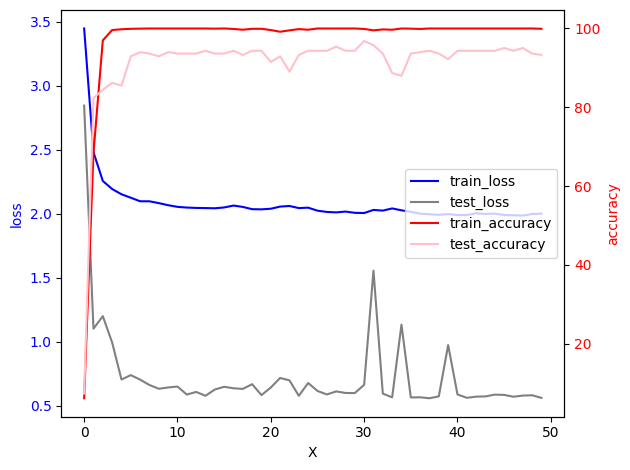

In [12]:
args.plot_loss_curve = True
if args.plot_loss_curve:
    # fig = plt.figure()
    fig, ax1 = plt.subplots()

    # 绘制第一个数据，使用左侧y轴
    ax1.plot(range(args.epochs), train_losses, 'blue', label="train_loss")
    ax1.plot(range(args.epochs), test_losses, 'gray', label="test_loss")
    ax1.set_xlabel('X')
    ax1.set_ylabel('loss', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # 创建第二个坐标轴，共享x轴但y轴在右侧
    ax2 = ax1.twinx()
    ax2.plot(range(args.epochs), train_accuracies, 'red', label="train_accuracy")
    ax2.plot(range(args.epochs), test_accuracies, 'pink', label="test_accuracy")
    ax2.set_ylabel('accuracy', color='r')
    ax2.tick_params(axis='y', labelcolor='r')


    fig.tight_layout()  # 自动调整布局以避免重叠

    # # 获取两个坐标轴上的线条和标签
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc=5)
    # plt.legend(['train_losses', 'train_accuracies', 'test_accuracies'], loc='upper right')
    # plt.xlabel('number of training examples seen')
    # plt.ylabel('Accuracy')
    plt.savefig(os.path.join(args.result_dir, "learning_curve.png"), dpi=200)

# TSNE

In [13]:
# with torch.no_grad():
#     for idx_o, (data, _, target) in enumerate(test_loader):
#         target = target - 1
#         data = data.to(args.device)
        
#         output = super_head(net(data))
#         target = target.to(args.device)

#         for idx, _ in enumerate(output.cpu().numpy()):
#             # print(output.cpu().numpy().shape)
#             if idx == 0 and idx_o == 0:
#                 list_output = output.cpu().numpy()[idx]
#                 list_target = target.cpu().numpy()[idx]
#             # print(list_output.shape, list_target.shape)

#             if idx < 100:
#                 list_output = np.vstack((list_output, output.cpu().numpy()[idx]))
#                 list_target = np.append(list_target, target.cpu().numpy()[idx])

In [14]:
# tsne = TSNE()

# out = tsne.fit_transform(list_output)
# fig, ax = plt.subplots()
# ax.set_axis_off()
# ax.xaxis.set_visible(False)
# ax.yaxis.set_visible(False)
# # fig.set_size_inches(label.shape[1] * scale / dpi, label.shape[0] * scale / dpi)
# plt.gca().xaxis.set_major_locator(plt.NullLocator())
# plt.gca().yaxis.set_major_locator(plt.NullLocator())
# plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

# label = ["Broccoli-weeds-1","Broccoli-weeds-2","Fallow","Fallow-rough-plow",
#          "Fallow-smooth","Stubble","Celery","Grapes-untrained",
#          "Soil-senesced-develop","Corn-weeds","Lettuce-4wk","Lettuce-5wk",
#          "Lettuce-6wk","Lettuce-7wk","Vinyard-untrained",
#          "Vinyard-vertical-trellis"]
# for i in range(class_num):
#     indices = list_target  == i
#     x, y = out[indices].T
#     # plt.scatter(x, y, s=5, label=label[i])
#     plt.scatter(x, y, s=5, label=str(i+1))
# plt.legend(loc=2,bbox_to_anchor=(1.05,1.0),borderaxespad = 0., fontsize=12)
# plt.savefig(args.result_dir  + '/tsneFull' + '.png', dpi=400, bbox_inches="tight")